# Memory Experiment — Triangular Color Code

6-6-6 hexagonal color code with space-multiplexed syndrome extraction. Other SE circuit blocks to be integrated.

In [1]:
import sys
from pathlib import Path
import numpy as np

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.ir.qec_system import QECSystem
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.color_code import ColorCode, ColorCodeExtractionBlock


In [2]:
from lightstim.noise.config import NoiseConfig

p = 1e-3
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)


## Color Code Memory (d=3)

In [3]:
d = 3
code = ColorCode(distance=d)
system = QECSystem()
system.add_patch(code, name="color")

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=ColorCodeExtractionBlock,
    rounds=d,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="Z", # "Z" or "X"
)
circuit_d3 = exp.build()
print(f"Qubits: {circuit_d3.num_qubits}  Detectors: {circuit_d3.num_detectors}")
# circuit_d3

Qubits: 13  Detectors: 18


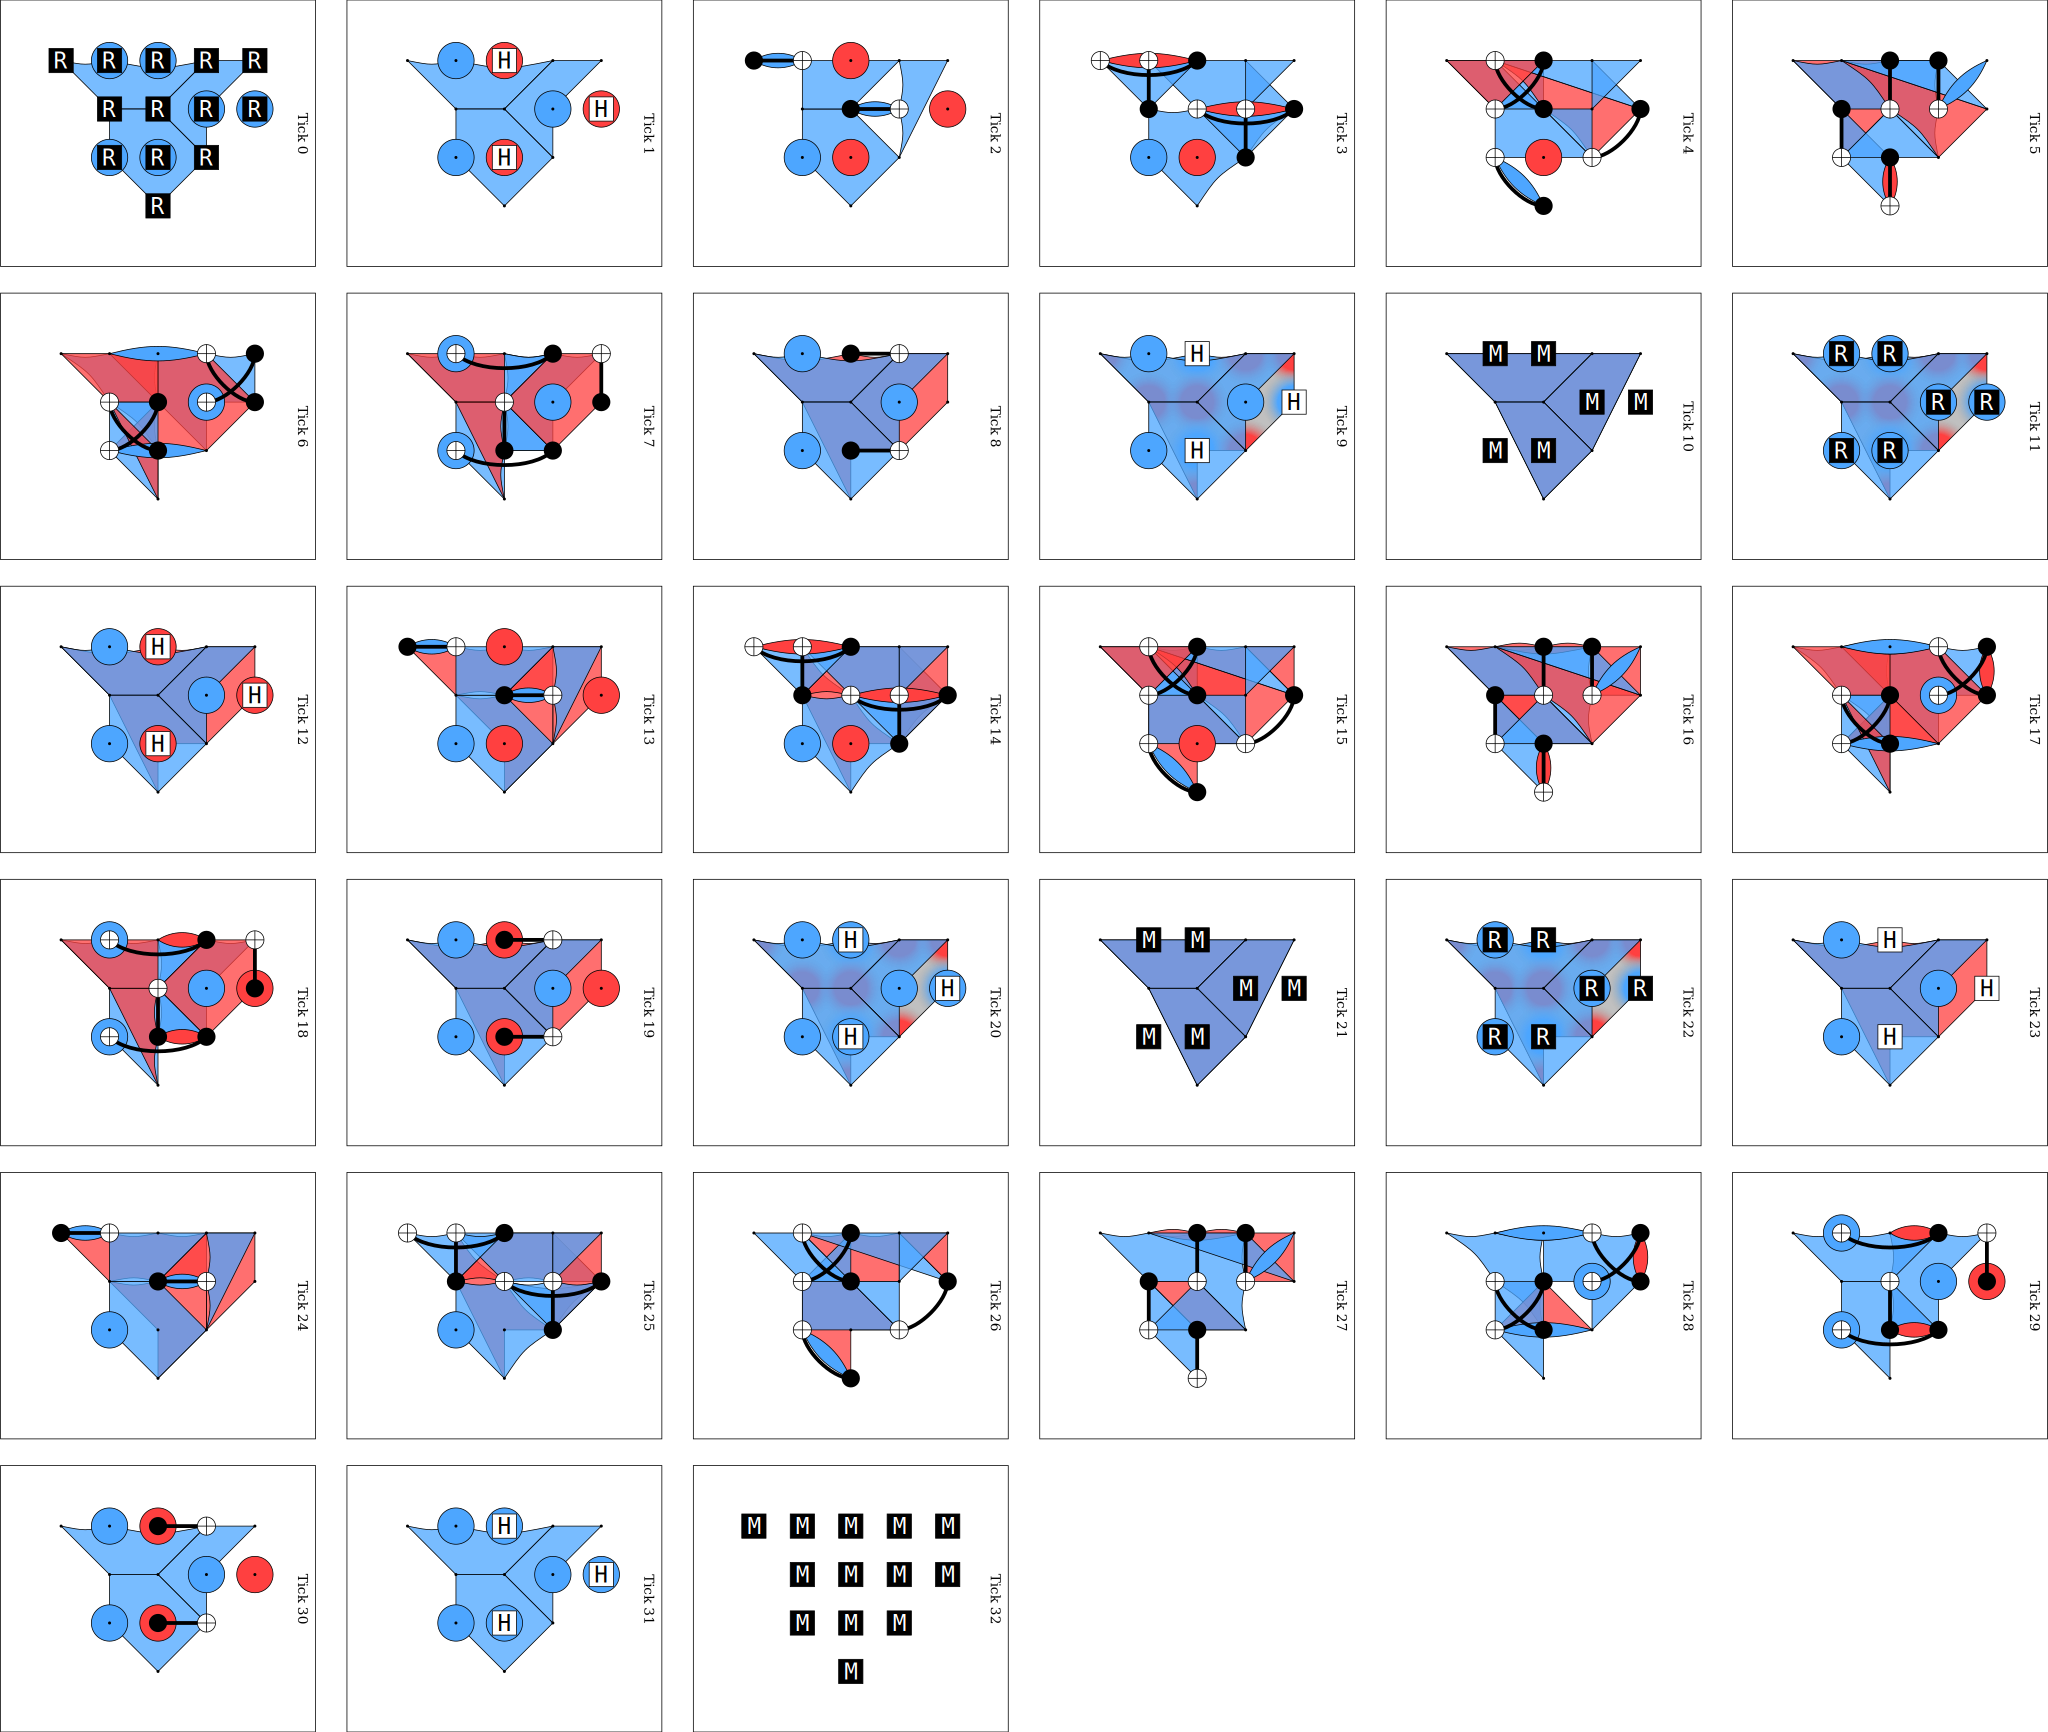

In [4]:
circuit_d3.without_noise().diagram("detslice-with-ops-svg")
# circuit_d3.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])

## Color Code d=5

In [5]:
d = 5
code = ColorCode(distance=d)
system = QECSystem()
system.add_patch(code, name="color_d5")

exp = MemoryExperiment(
    qec_system=system,
    extraction_block_class=ColorCodeExtractionBlock,
    rounds=3,
    noise_params=noise_params,
    noise_model="circuit_level",
    basis="X", # "Z" or "X"
)
circuit_d5 = exp.build()
print(f"Qubits: {circuit_d5.num_qubits}  Detectors: {circuit_d5.num_detectors}")


Qubits: 37  Detectors: 54


In [6]:
# circuit_d5.without_noise().diagram("detslice-with-ops-svg")
# circuit_d5.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])